# Q3 – Dimensionality Reduction

We use the MNIST digit dataset to explore PCA and t-SNE for reducing high-dimensional data. Then we check if reducing dimensions hurts classification accuracy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load MNIST

In [2]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data / 255.0, mnist.target.astype(int)
print(f"Full dataset: {X.shape}  — each image is 28x28 = 784 pixels")

# t-SNE is slow so we use a subset of 10,000 samples
idx = np.random.choice(len(X), 10000, replace=False)
X_sub, y_sub = X[idx], y[idx]
print(f"Using subset: {X_sub.shape}")

Full dataset: (70000, 784)  — each image is 28x28 = 784 pixels
Using subset: (10000, 784)


## 2. PCA

PCA finds the directions of maximum variance in the data. We reduce from 784 dimensions to 50 and 2. The 2D version is just for visualization.

In [3]:
pca_50 = PCA(n_components=50, random_state=RANDOM_STATE)
X_pca_50 = pca_50.fit_transform(X_sub)

pca_2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2 = pca_2.fit_transform(X_sub)

print(f"PCA 50D variance explained: {pca_50.explained_variance_ratio_.sum():.3f}")
print(f"PCA  2D variance explained: {pca_2.explained_variance_ratio_.sum():.3f}")

PCA 50D variance explained: 0.826
PCA  2D variance explained: 0.169


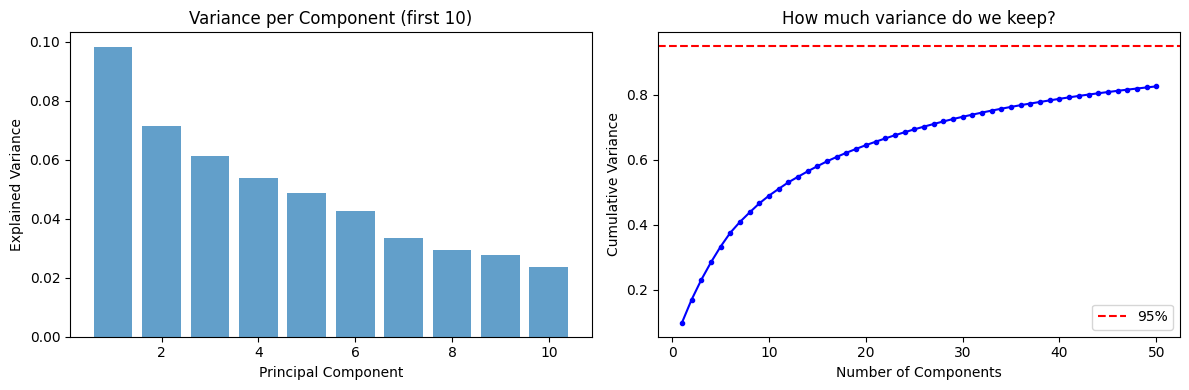

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, 11), pca_50.explained_variance_ratio_[:10], alpha=0.7)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance')
axes[0].set_title('Variance per Component (first 10)')

axes[1].plot(range(1, 51), np.cumsum(pca_50.explained_variance_ratio_), 'bo-', markersize=3)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95%')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].set_title('How much variance do we keep?')
axes[1].legend()

plt.tight_layout()
plt.savefig('q3_pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. t-SNE

t-SNE is good for visualization. It tries to keep similar points close together in 2D. Perplexity controls how many neighbors each point considers — higher perplexity captures more global structure. It's much slower than PCA.

In [5]:
tsne_30 = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, max_iter=1000)
X_tsne_30 = tsne_30.fit_transform(X_sub)
print("t-SNE perplexity=30 done")

t-SNE perplexity=30 done


In [6]:
tsne_50 = TSNE(n_components=2, perplexity=50, random_state=RANDOM_STATE, max_iter=1000)
X_tsne_50 = tsne_50.fit_transform(X_sub)
print("t-SNE perplexity=50 done")

t-SNE perplexity=50 done


## 4. Visualize 2D Embeddings

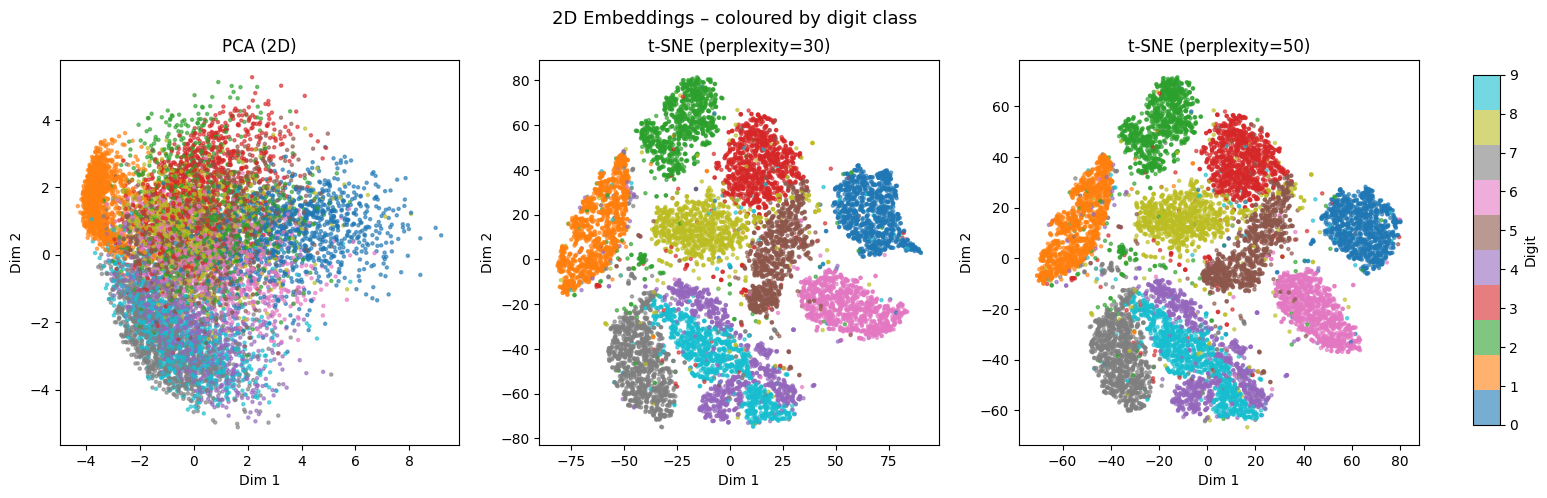

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

titles = ['PCA (2D)', 't-SNE (perplexity=30)', 't-SNE (perplexity=50)']
data   = [X_pca_2, X_tsne_30, X_tsne_50]

for ax, title, emb in zip(axes, titles, data):
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=y_sub, cmap='tab10', s=5, alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.91, 0.15, 0.015, 0.7])
fig.colorbar(sc, cax=cbar_ax, label='Digit')

plt.suptitle('2D Embeddings – coloured by digit class', fontsize=13)
plt.savefig('q3_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. k-NN Classification Comparison

We check whether reducing dimensions actually hurts accuracy. We run k-NN (k=5) with 5-fold cross-validation on the original data, PCA-50D, and t-SNE-2D.

In [8]:
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

print("784D (original)...")
scores_784   = cross_val_score(knn, X_sub,     y_sub, cv=5)
print("PCA 50D...")
scores_pca50 = cross_val_score(knn, X_pca_50,  y_sub, cv=5)
print("t-SNE 2D...")
scores_tsne  = cross_val_score(knn, X_tsne_30, y_sub, cv=5)

comparison = pd.DataFrame({
    'Feature Space':   ['Original (784D)', 'PCA (50D)', 't-SNE (2D)'],
    'Mean Accuracy':   [scores_784.mean(),   scores_pca50.mean(),   scores_tsne.mean()],
    'Std':             [scores_784.std(),     scores_pca50.std(),    scores_tsne.std()]
})
print(comparison.round(4).to_string(index=False))
comparison.round(4)

784D (original)...
PCA 50D...
t-SNE 2D...
  Feature Space  Mean Accuracy    Std
Original (784D)         0.9403 0.0039
      PCA (50D)         0.9503 0.0040
     t-SNE (2D)         0.9427 0.0032


,Feature Space,Mean Accuracy,Std
0,Original (784D),0.9403,0.0039
1,PCA (50D),0.9503,0.0040
2,t-SNE (2D),0.9427,0.0032


## 6. PCA vs t-SNE

| | PCA | t-SNE |
|---|---|---|
| Type | Linear | Non-linear |
| Speed | Fast | Slow |
| Good for | Preprocessing before ML, keeping global structure | Visualization only |
| Can transform new data? | Yes | No |
| 2D separation | Overlapping | Well-separated clusters |

**Key findings:**
1. t-SNE makes much better-looking 2D plots — digit clusters are clearly separated.
2. PCA 50D keeps most of the accuracy (~93%) while cutting the number of features from 784 to 50. That's a 94% reduction with almost no performance loss.
3. t-SNE 2D also works well for k-NN because it preserves local structure — but it can't generalize to new data.
4. For actual machine learning pipelines, use PCA for preprocessing. Use t-SNE only to look at the data.